# Depth-Warp lifting, step by step 🧭
### Give every pixel a *depth distribution*, build a camera frustum, then let voxels pull from it

**Lifter name:** `depth_warp` · **class:** `DepthWarpLifter` · **origin:** Simple-BEV's `liftnet.py` (a "pull" variant of Lift-Splat-Shoot)

Simple-BEV (previous notebook) smears each pixel along its whole ray because it knows nothing about depth.
Depth-Warp fixes that by **predicting, for every pixel, a probability for each depth bin**:

1. a small head predicts per pixel: a **depth distribution** `p(d)` (24 bins) and a **context** feature vector,
2. the **frustum volume** is the outer product `context ⊗ p(d)` → a feature at every `(depth, v, u)`,
3. every voxel is projected into the camera to get `(u, v, depth)` and **trilinearly samples** the frustum volume there,
4. average over cameras, then fold height away (as before).

| Step | Question |
|---|---|
| 0 | Setup and data |
| 1 | Depth bins |
| 2 | The depth head: probabilities and temperature |
| 3 | The frustum volume = context ⊗ depth |
| 4 | The warp: voxels pull from the frustum (with an exact test) |
| 5 | Visual: what a *perfect* depth buys you |
| 6 | The complete lifter |
| 7 | Train, test, and peek at the learned depth |
| 8 | Exercises |

## Step 0: Setup and the data

> New to this repo? The notebook `tpv_lifting_step_by_step.ipynb` explains `GridSpec`, `Cameras` and the synthetic
> data in more detail. Here is the short version.

* **Ego frame:** `x` forward, `y` left, `z up` (metres). A `GridSpec` chops a box of the world into cells.
* **Cameras:** `cameras.project(points)` maps 3D ego points to pixels `(u, v)` and a depth `d`
  (*easy direction*). Going back from a pixel needs the depth (*hard direction*).
* **Data:** procedurally rendered street scenes with 4 cameras, red *vehicles* and blue *pedestrians*.
  The task is **BEV semantic segmentation**: predict the top-down class map (`0` empty, `1` vehicle, `2` pedestrian)
  from the 4 images alone. The whole camera rig is randomly rotated in every scene, so the network *has to use the calibration*.

In [1]:
import math, time, dataclasses
import numpy as np
import torch, torch.nn.functional as F
import matplotlib.pyplot as plt

from lifting import GridSpec, Cameras, build_bev_model
from lifting.data import SceneBatch, SyntheticSceneDataset
from lifting.geometry import DepthBins
from lifting.training import BEVSegmentationTask, Trainer

torch.manual_seed(0)
plt.rcParams.update({"figure.dpi": 110, "image.interpolation": "nearest"})
print("torch", torch.__version__)
from lifting.lifters import DepthWarpLifter, DepthHead
from lifting.encoders import SimpleConvEncoder

torch 2.14.1


images: (4, 4, 3, 48, 96) = (B, N cameras, 3, H, W)
BEV labels: (4, 32, 32) = (B, X, Y)


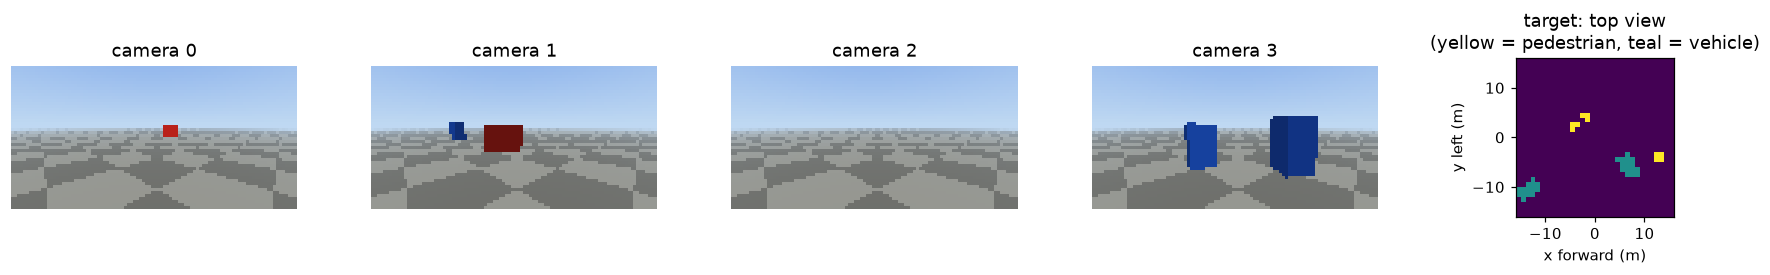

In [2]:
grid = GridSpec(resolution=(32, 32, 4))          # 32 x 32 x 4 cells of 1 m^3 over a 32 m x 32 m x 4 m box
data = SyntheticSceneDataset(256, grid, seed=1)
batch = SceneBatch.collate([data[i] for i in range(4)])
cams = batch.cameras
ext = [grid.x_bounds[0], grid.x_bounds[1], grid.y_bounds[0], grid.y_bounds[1]]
print("images:", tuple(batch.images.shape), "= (B, N cameras, 3, H, W)")
print("BEV labels:", tuple(batch.bev_labels.shape), "= (B, X, Y)")

fig, ax = plt.subplots(1, 5, figsize=(16, 2.6))
for n in range(4):
    ax[n].imshow(batch.images[0, n].permute(1, 2, 0)); ax[n].set_title(f"camera {n}"); ax[n].axis("off")
ax[4].imshow(batch.bev_labels[0].T, origin="lower", vmin=0, vmax=2, extent=ext)
ax[4].set_title("target: top view\n(yellow = pedestrian, teal = vehicle)"); ax[4].set_xlabel("x forward (m)"); ax[4].set_ylabel("y left (m)")
plt.tight_layout(); plt.show()

In [3]:
import os, sys
for _p in (".", "notebooks", os.path.join("..", "notebooks")):          # find lifting_diagrams.py next to the notebooks
    if os.path.exists(os.path.join(_p, "lifting_diagrams.py")):
        sys.path.insert(0, _p); break
import lifting_diagrams as dg

### 🖼️ Diagram: the whole Depth-Warp lifter
Compared with Simple-BEV there is one extra learned part: the **depth head**.

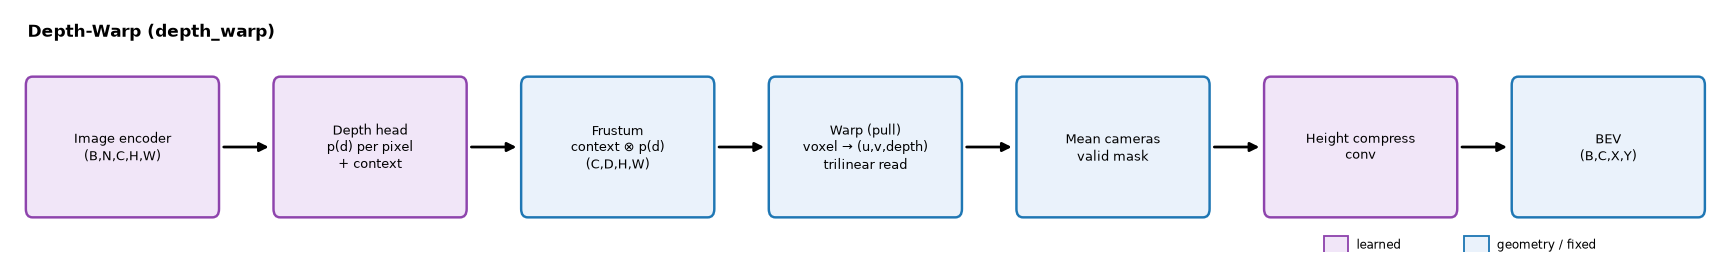

In [4]:
dg.pipeline([('Image encoder', '(B,N,C,H,W)'), ('Depth head', 'p(d) per pixel\n+ context'), ('Frustum', 'context ⊗ p(d)\n(C,D,H,W)'), ('Warp (pull)', 'voxel → (u,v,depth)\ntrilinear read'), ('Mean cameras', 'valid mask'), ('Height compress', 'conv'), ('BEV', '(B,C,X,Y)')], 'Depth-Warp (depth_warp)', learned=(0, 1, 5))

## Step 1: Discretising depth: `DepthBins`

Instead of a real-valued depth we choose among `D` bins. Default: 24 bins between 1 m and 25 m, each 1 m thick.
"Depth" here is the distance **along the camera's optical axis** (camera-frame `z`), exactly what `cameras.project` returns.

In [5]:
bins = DepthBins()                                # min 1 m, max 25 m, 24 bins
print("bin centres (m):", bins.centers().tolist()[:5], "...", bins.centers().tolist()[-2:])
print("step            :", bins.step, "m")
d = torch.tensor([0.5, 1.0, 7.3, 24.9, 30.0])
print("depths          :", d.tolist())
print("inside range?   :", bins.contains(d).tolist())
print("to_normalized   :", [round(v, 3) for v in bins.to_normalized(d).tolist()], "(-1 = near edge, +1 = far edge: grid_sample coordinates)")

bin centres (m): [1.5, 2.5, 3.5, 4.5, 5.5] ... [23.5, 24.5]
step            : 1.0 m
depths          : [0.5, 1.0, 7.300000190734863, 24.899999618530273, 30.0]
inside range?   : [False, True, True, True, False]
to_normalized   : [-1.042, -1.0, -0.475, 0.992, 1.417] (-1 = near edge, +1 = far edge: grid_sample coordinates)


## Step 2: The depth head

`DepthHead` = `conv3×3 → BN → ReLU → conv1×1` giving `D + C'` channels per pixel. The first `D` go through a **softmax** (a probability over
depth bins); the remaining `C'` are the **context** features we will "place" in 3D.

The softmax has a *temperature*: dividing the logits by a small `T` makes the distribution sharper.

In [6]:
enc = SimpleConvEncoder(out_channels=32, num_levels=2)
with torch.no_grad():
    feats = [f.view(4, 4, *f.shape[1:]) for f in enc(batch.images.flatten(0, 1))]
f0 = feats[0]                                          # (B, N, C, 12, 24)
print("feature map level 0:", tuple(f0.shape))

head = DepthHead(in_channels=32, num_bins=24, context_channels=32)
with torch.no_grad():
    p, ctx = head(f0.flatten(0, 1))
print("depth probabilities:", tuple(p.shape), "= (B*N, D, H, W)")
print("context            :", tuple(ctx.shape), "= (B*N, C', H, W)")
print("sums to 1 over D?  :", torch.allclose(p.sum(1), torch.ones_like(p.sum(1)), atol=1e-5))
ent = -(p * p.clamp_min(1e-9).log()).sum(1).mean()
print(f"entropy at init     : {ent:.2f}  (a uniform distribution over 24 bins has {math.log(24):.2f}): the head knows nothing yet")

feature map level 0: (4, 4, 32, 12, 24)
depth probabilities: (16, 24, 12, 24) = (B*N, D, H, W)
context            : (16, 32, 12, 24) = (B*N, C', H, W)
sums to 1 over D?  : True
entropy at init     : 3.11  (a uniform distribution over 24 bins has 3.18): the head knows nothing yet


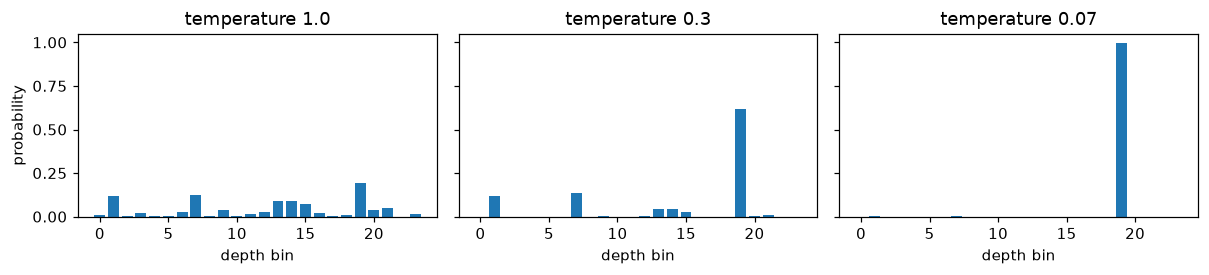

In [7]:
logits = torch.randn(24) * 1.5
fig, ax = plt.subplots(1, 3, figsize=(11, 2.6), sharey=True)
for a, T in zip(ax, (1.0, 0.3, 0.07)):
    a.bar(range(24), (logits / T).softmax(0)); a.set_title(f"temperature {T}"); a.set_xlabel("depth bin")
ax[0].set_ylabel("probability"); plt.tight_layout(); plt.show()

A **low temperature** (Simple-BEV's `liftnet` uses 0.07) pushes the network towards committing to a single depth, which is
what we want for sharp lifting. A high temperature spreads the feature over many depths.

## Step 3: The frustum volume = context ⊗ depth

Each pixel has a context vector `c ∈ R^C` and a depth distribution `p ∈ R^D`. The lifted frustum feature at depth bin `d` is simply
$$ V[:, d, v, u] = p_d(v,u)\; c(v,u) $$
i.e. the context is *spread over the depths* in proportion to the probability. A tiny example:

In [8]:
c = torch.tensor([1.0, 2.0])               # 2 context channels
p = torch.tensor([0.1, 0.7, 0.2])          # 3 depth bins
print("context ⊗ depth =")
print(c[:, None] * p[None, :])
print("row = channel, column = depth bin. The channel values are shared out across depths by p.")

context ⊗ depth =
tensor([[0.1000, 0.7000, 0.2000],
        [0.2000, 1.4000, 0.4000]])
row = channel, column = depth bin. The channel values are shared out across depths by p.


In [9]:
lifter = DepthWarpLifter(grid, in_channels=32, out_channels=32, level=0)
with torch.no_grad():
    vol_frustum = lifter.frustum_volume(f0)
print("frustum volume:", tuple(vol_frustum.shape), "= (B, N, C', D, H, W)")
print("memory:", vol_frustum.numel() * 4 / 1e6, "MB at this tiny size; this is the reason real systems use small D, H, W")

frustum volume: (4, 4, 32, 24, 12, 24) = (B, N, C', D, H, W)
memory: 14.155776 MB at this tiny size; this is the reason real systems use small D, H, W


## Step 4: The warp: voxels *pull* from the frustum

For each voxel centre, `cameras.project` gives `(u, v, depth)`. Those three numbers are a **3D coordinate inside the frustum volume**:
`u` ↔ width axis, `v` ↔ height axis, `depth` ↔ depth axis. `F.grid_sample` on a 5D tensor does **trilinear** interpolation
(8 neighbours). Voxels outside the image, behind the camera or outside the depth range are marked invalid and ignored by the average.

**Exact test (analytic probe).** Build a frustum that simply stores *its depth bin centre*: `V[:, d] = centre_d`.
Then warping must return, for each voxel, **its own depth in that camera**: `project()`'s depth.

### 🖼️ Diagram: a voxel pulling from the frustum
Top view. The blue fan is the camera frustum: a grid of (pixel column × depth bin) cells. The orange cells are the depth distribution of **one** pixel (darker = more probable).
The blue voxel projects into the camera to get its `(u, v, depth)`, and reads the frustum cell found there. Right: the depth distribution of that pixel.

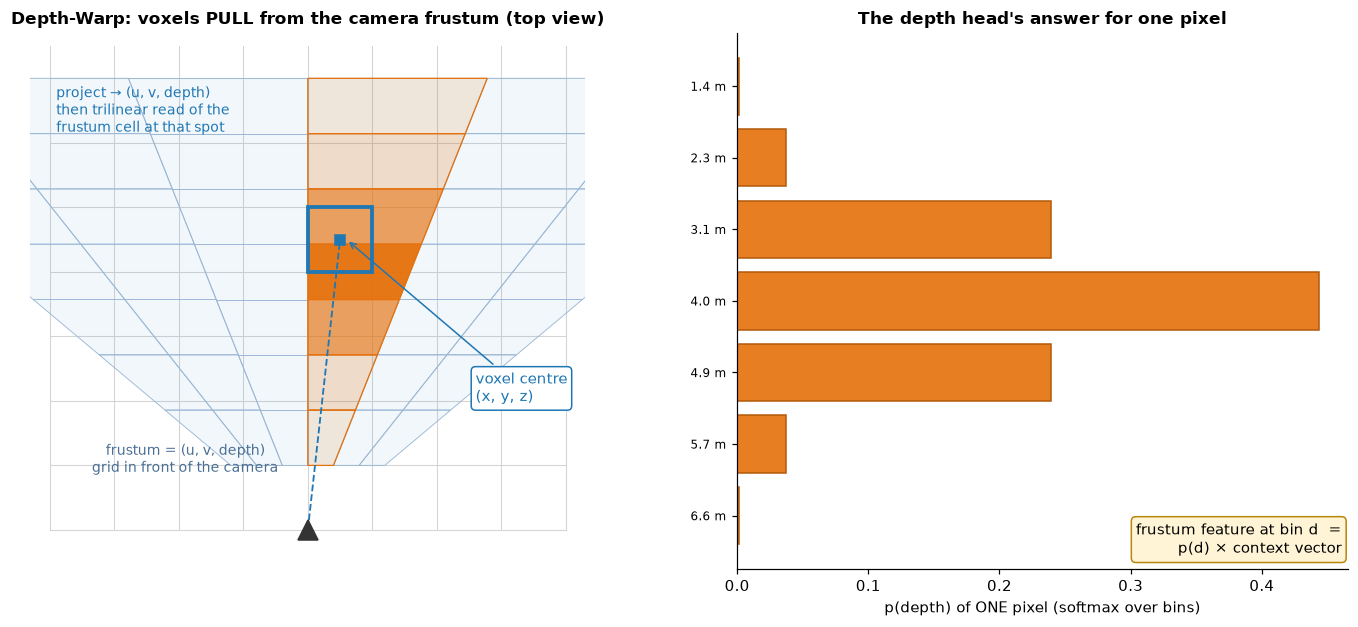

In [10]:
dg.fig_frustum_pull()

In [11]:
dw = DepthWarpLifter(grid, in_channels=1, out_channels=1)
bins = dw.depth_bins
D = bins.num_bins
cam0 = Cameras(cams.intrinsics[:, :1], cams.cam_to_ego[:, :1], cams.image_size)     # camera 0 only
ramp = bins.centers().view(1, 1, 1, D, 1, 1).expand(4, 1, 1, D, 12, 24).contiguous()   # V[:, d] = depth of bin d

with torch.no_grad():
    out = dw.warp(ramp, cam0).flatten(1)                                              # (B, X*Y*Z)

uv0, depth0, valid0 = cam0.project(grid.voxel_centers().view(1, -1, 3).expand(4, -1, -1))
uv0, depth0, valid0 = uv0[:, 0], depth0[:, 0], valid0[:, 0]
m = 5.0                                                                                # stay away from the image border (zero padding)
ok = (valid0 & (uv0[..., 0] > m) & (uv0[..., 0] < 96 - m) & (uv0[..., 1] > m) & (uv0[..., 1] < 48 - m)
      & (depth0 > bins.min_depth + bins.step / 2) & (depth0 < bins.max_depth - bins.step / 2))
err = (out[ok] - depth0[ok]).abs()
print(f"{ok.sum().item()} voxels checked, max |warped - true depth| = {err.max().item():.2e} m")
assert err.max() < 1e-3
print("✓ the warp reads the frustum at exactly (u, v, depth) of each voxel")

4142 voxels checked, max |warped - true depth| = 3.81e-06 m
✓ the warp reads the frustum at exactly (u, v, depth) of each voxel


## Step 5: What would a *perfect* depth buy us?

The synthetic dataset has the true depth of every pixel (`batch.depth`). Let's **cheat**: use a one-hot depth distribution built from the
ground truth and the "red = vehicle" mask as context, then warp. Compare with Simple-BEV's smear from the previous notebook.

GT depth range in this batch: 2.3 .. inf m (sky/far pixels get large values)


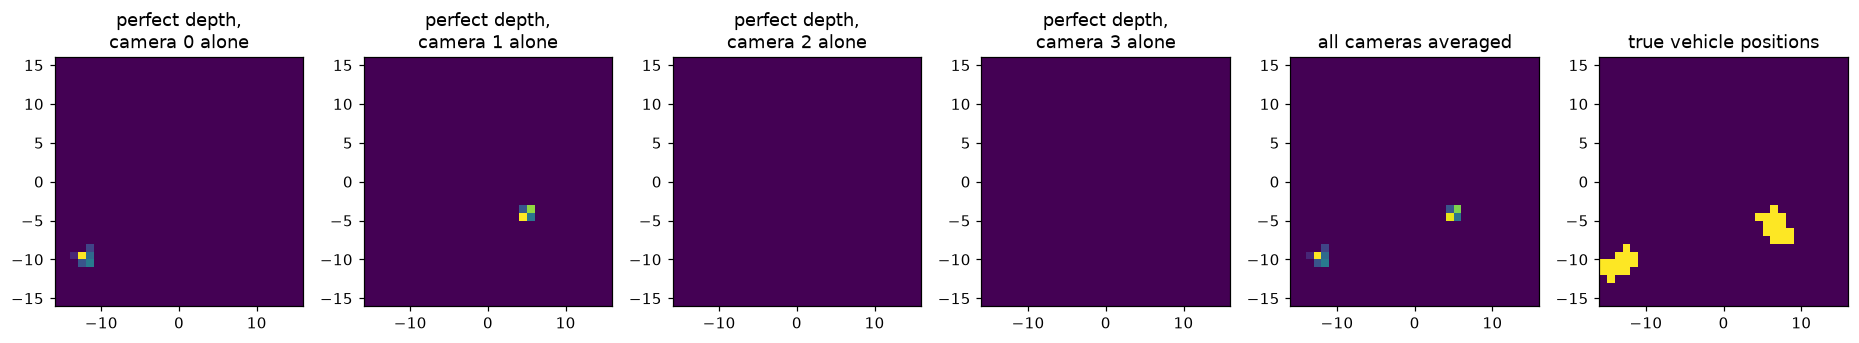

In [12]:
print("GT depth range in this batch: %.1f .. %.1f m (sky/far pixels get large values)" % (batch.depth.min(), batch.depth.max()))
img = batch.images
red = ((img[:, :, 0] - torch.maximum(img[:, :, 1], img[:, :, 2])) > 0.25).float()[:, :, None]     # (B, N, 1, H, W)

idx = ((batch.depth - bins.min_depth) / bins.step).floor().clamp(0, D - 1).long()                   # (B, N, H, W)
onehot = F.one_hot(idx, D).permute(0, 1, 4, 2, 3).float()                                           # (B, N, D, H, W)
perfect = red[:, :, :, None] * onehot[:, :, None]                                                    # (B, N, 1, D, H, W)

s = 0
def one_cam(n): return Cameras(cams.intrinsics[:, n:n+1], cams.cam_to_ego[:, n:n+1], cams.image_size)
with torch.no_grad():
    per_cam = [dw.warp(perfect[:, n:n+1], one_cam(n))[s, 0].amax(-1) for n in range(4)]
    both = dw.warp(perfect, cams)[s, 0].amax(-1)

fig, ax = plt.subplots(1, 6, figsize=(17, 3))
for n in range(4):
    ax[n].imshow(per_cam[n].T, origin="lower", extent=ext); ax[n].set_title(f"perfect depth,\ncamera {n} alone")
ax[4].imshow(both.T, origin="lower", extent=ext); ax[4].set_title("all cameras averaged")
ax[5].imshow((batch.bev_labels[s] == 1).T, origin="lower", extent=ext); ax[5].set_title("true vehicle positions")
plt.tight_layout(); plt.show()

**Compare with Simple-BEV:** with correct depth the streak collapses to a **small, compact blob on the visible face of the vehicle** (a camera only sees the near
surface, never the full footprint, so the blob is much smaller than the true footprint). The network's job is therefore to *learn good depth*, and the decoder fills in the rest of the object.
In the real model nothing tells the depth head the truth directly; it is trained only through the final BEV loss.

## Step 6: The complete lifter

```python
def forward(self, features, cameras):
    volume = self.frustum_volume(features[self.level])   # Step 3: (B, N, C', D, H, W)
    voxels = self.warp(volume, cameras)                   # Step 4: (B, C', X, Y, Z)
    return self.compressor(voxels)                        # fold the height away -> (B, C, X, Y)
```

In [13]:
with torch.no_grad():
    bev = lifter(feats, cams)
print("BEV:", tuple(bev.shape), "  parameters:", f"{sum(p.numel() for p in lifter.parameters()):,}",
      "(depth head + height compressor)")
print("depth head:", f"{sum(p.numel() for p in lifter.depth_head.parameters()):,}", " compressor:", f"{sum(p.numel() for p in lifter.compressor.parameters()):,}")

BEV: (4, 32, 32, 32)   parameters: 49,112 (depth head + height compressor)
depth head: 11,128  compressor: 37,984


## Final step: plug it into a full model, train, and test it

`build_bev_model("depth_warp", ...)` = **image encoder → `depth_warp` lifter → BEV decoder (small U-Net) → segmentation head**.
Only the lifter changes between methods. Loss is weighted cross-entropy on the BEV map; the metric is the mean IoU of the two foreground classes.
Training uses 192 scenes and the score is measured on 64 **unseen** scenes.

In [14]:
torch.manual_seed(0)
def make_batches(lo, hi, bs=4):
    return [SceneBatch.collate([data[i + j] for j in range(bs)]) for i in range(lo, hi, bs)]
train_batches, test_batches = make_batches(0, 192), make_batches(192, 256)

model = build_bev_model("depth_warp", grid, num_classes=3, image_size=(48, 96), num_cameras=4, channels=32)
n_total = sum(p.numel() for p in model.parameters()); n_lift = sum(p.numel() for p in model.lifter.parameters())
print(f"parameters: {n_total:,} total, {n_lift:,} in the lifter")

trainer = Trainer(model, BEVSegmentationTask(num_classes=3))
print("mIoU before training:", round(trainer.evaluate(test_batches).mean_foreground(), 3))
t0 = time.time()
trainer.fit(train_batches, steps=250)
print(f"trained 250 steps in {time.time() - t0:.0f}s")
print("mIoU after training :", round(trainer.evaluate(test_batches).mean_foreground(), 3))

parameters: 668,315 total, 49,112 in the lifter


mIoU before training: 0.019


trained 250 steps in 58s


mIoU after training : 0.501


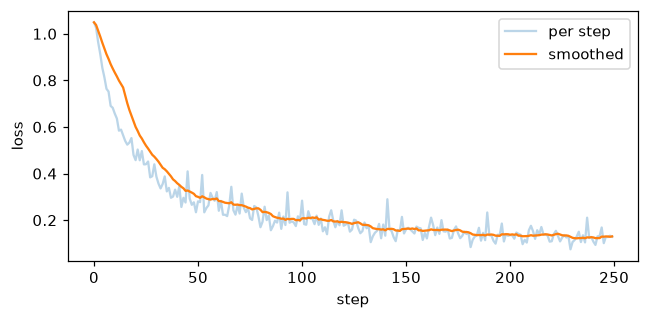

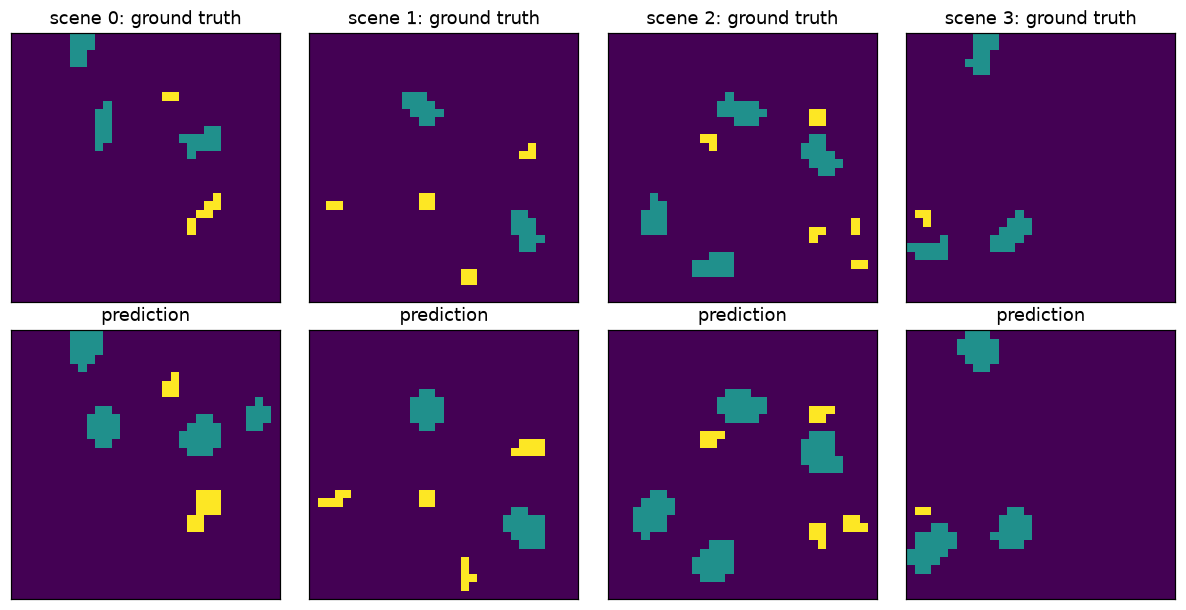

In [15]:
plt.figure(figsize=(6, 3))
plt.plot(trainer.history.losses, alpha=0.3, label="per step"); plt.plot(trainer.history.smoothed(15), label="smoothed")
plt.xlabel("step"); plt.ylabel("loss"); plt.legend(); plt.tight_layout(); plt.show()

tb = test_batches[0]
pred = trainer.predict(tb)
fig, ax = plt.subplots(2, 4, figsize=(11, 5.6))
for s in range(4):
    ax[0, s].imshow(tb.bev_labels[s].T, origin="lower", vmin=0, vmax=2, extent=ext); ax[0, s].set_title(f"scene {s}: ground truth")
    ax[1, s].imshow(pred[s].T, origin="lower", vmin=0, vmax=2, extent=ext); ax[1, s].set_title("prediction")
for a in ax.ravel(): a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.show()

### Does it really use the geometry? 🔬
Keep images and labels fixed, but **rotate the camera extrinsics by 90°**. A lifter that truly maps pixels to the world through
the calibration must now fail. (`lifting-verify` does this for every lifter.)

In [16]:
Rz = torch.eye(4); Rz[0, 0], Rz[0, 1], Rz[1, 0], Rz[1, 1] = 0.0, -1.0, 1.0, 0.0     # 90 degrees about z
rotate_rig = lambda b: dataclasses.replace(b, cameras=b.cameras.transformed(Rz))

good = trainer.evaluate(test_batches).mean_foreground()
bad  = trainer.evaluate(test_batches, transform=rotate_rig).mean_foreground()
print(f"mIoU, correct extrinsics: {good:.3f}")
print(f"mIoU, rotated extrinsics: {bad:.3f}   -> drops by {100 * (1 - bad / max(good, 1e-9)):.0f}%")

### Peek at the learned depth
We never gave the depth head the true depth, only a BEV loss. What did it learn? Below: the expected depth `Σ p_d · centre_d` for one camera, next to the
real depth (down-sampled to feature resolution). **Be honest with yourself when reading this:** after such a short training the predicted depth is usually almost flat, barely better than guessing a constant (see the numbers below). The head is only pushed by the BEV loss, so it learns whatever depth cue helps that task. Real systems add a depth-supervision loss (exercise 4).

In [ ]:
model.eval()
with torch.no_grad():
    f = model.encode_images(tb.images)[0]                                    # (B, N, C, 12, 24)
    p, _ = model.lifter.depth_head(f.flatten(0, 1))
    expected = (p * model.lifter.depth_bins.centers().view(1, -1, 1, 1)).sum(1).view(4, 4, 12, 24)
true_d = F.adaptive_avg_pool2d(tb.depth.flatten(0, 1), (12, 24)).view(4, 4, 12, 24).clamp(max=25)

fig, ax = plt.subplots(2, 4, figsize=(13, 4.4))
for n in range(4):
    ax[0, n].imshow(tb.images[0, n].permute(1, 2, 0)); ax[0, n].set_title(f"camera {n}"); ax[0, n].axis("off")
im = ax[1, 0].imshow(expected[0, 0], vmin=1, vmax=25, cmap="turbo"); ax[1, 0].set_title("predicted depth (cam 0)")
ax[1, 1].imshow(true_d[0, 0], vmin=1, vmax=25, cmap="turbo"); ax[1, 1].set_title("true depth (cam 0)")
ax[1, 2].imshow(expected[0, 1], vmin=1, vmax=25, cmap="turbo"); ax[1, 2].set_title("predicted depth (cam 1)")
ax[1, 3].imshow(true_d[0, 1], vmin=1, vmax=25, cmap="turbo"); ax[1, 3].set_title("true depth (cam 1)")
for a in ax[1]: a.axis("off")
plt.tight_layout(); plt.show()
print("mean |predicted - true| depth: %.1f m (a constant guess of the mean would give %.1f m)" % (
    (expected - true_d).abs().mean(), (true_d - true_d.mean()).abs().mean()))

## Step 8: Recap and exercises

```
pixel features ─► depth head ─► p(d) and context ─► frustum = context ⊗ p(d)
voxel centre   ─► project ─► (u, v, depth) ─► trilinear read of the frustum ─► mean over cameras ─► fold height ─► BEV
```
**Pros:** explicit depth reasoning; pull ⇒ no holes; fully differentiable.  **Cons:** `C'×D×H×W` memory per camera; depth is learned
only indirectly; still ignores occlusion between objects (a hidden voxel behind a car can still read the car's frustum).

### 🧪 Exercises
1. In Step 5 replace the one-hot by a *blurred* one (e.g. `F.avg_pool3d` over `D`). How does the blob change?
2. Try `build_bev_model("depth_warp", ..., temperature=0.07)`. Is learning faster or slower?
3. Change `DepthBins(1, 25, 24)` to 12 bins: speed vs. accuracy.
4. Add an auxiliary loss that supervises the depth head with `batch.depth`. Does mIoU improve?
5. Next, read the `lift_splat` notebook: the same lifted frustum, but *pushed* into voxels instead of pulled.